In [5]:
import gtsam
import numpy as np
import matplotlib.pyplot as plt
from gtbook.display import show
from gtsam.symbol_shorthand import X, L
from gtsam import symbolChr, symbolIndex
import gtsam.utils.plot as gtsam_plot
from utilities.utils import kstr, pose2_to_array, rotmat2
from data.data_generator_nonlinear import RobotSimulatorSE2, build_nonlinear_factor_graph, compute_error
from tuning import NonlinearSimParams, NonlinearFactorGraphParams
from utilities.cov_reorder import reorder_covariance_auto, sort_keys_human, elimination_keys
from models.dynamicmodels import OdometrySE2
from models.measurementmodels import RangeBearing

### Create factor graph

In [ ]:
from data.create_paths import make_circle_data, make_figure8_data

poses, landmarks, obs = make_circle_data(radius=5.0, n_poses=20, n_landmarks=30)  
poses, landmarks, obs = make_figure8_data(a=5.0, n_poses=30, n_landmarks=25)

# Create simulation configuration
simParams = NonlinearSimParams(
    poses=poses, 
    landmarks=landmarks, 
    observations=obs,
    Q_vec = np.array([0.05, 0.05, 0.02]),    # Process noise
    R_vec = np.array([0.05, 0.1]),          # Measurement
    P_x0_vec = np.array([0.01, 0.01, 0.01]), # Prior noise
    odom_seed=42,
    meas_seed=42,
)

# simParams = NonlinearSimParams(
#     poses=[
#         np.array([0.0, 0.0, 0.0]),  # X0
#         np.array([2.0, 0.0, 0.0]),  # X1
#         np.array([0.0, 0.0, 0.0])   # X2
#     ],
#     landmarks=[
#         np.array([2.0, 2.0]),  # L0
#         np.array([4.0, 2.0]),  # L1
#     ],
#     observations={ # could potentially use max distance to determine this
#         0: [0],     # X0 sees L0
#         1: [0],     # X1 sees L0
#         2: [0,1]    # X2 sees L0 & L1
#     },
#     Q_vec = np.array([0.02, 0.02, 0.01]),   # Process noise
#     R_vec = np.array([0.02, 0.05]),         # Measurement
#     P_x0_vec = np.array([0.01, 0.01, 0.01]) # Prior noise
# )

# simParams = NonlinearSimParams(
#     poses=[
#         np.array([0.0, 0.0, np.pi/2]),  # X0
#         np.array([0.0, 2.0, np.pi/2]),  # X1
#         np.array([0.0, 4.0, np.pi/2]),  # X2
#         np.array([0.0, 6.0, np.pi/2]),  # X3
#         np.array([0.0, 8.0, np.pi/2])   # X4

#     ],
#     landmarks=[
#         np.array([2.0, 2.0]),  # L0
#         np.array([4.0, 2.0]),  # L1
#         np.array([4.0, 4.0]),  # L2
#         np.array([6.0, 5.0]),  # L3
#         np.array([5.0, 7.0])   # L4
#     ],
#     observations={ # could potentially use max distance to determine this
#         0: [0,1,2],
#         1: [0,1,2,3,4],
#         2: [0,1,2],
#         3: [2,3,4],
#         4: [0,1,2,3,4]    
#     },
#     Q_vec = np.array([0.1, 0.1, 0.05]),     # Process noise
#     R_vec = np.array([0.1, 0.05]),          # Measurement
#     P_x0_vec = np.array([0.05, 0.05, 0.05]), # Prior noise

#     odom_seed=42,
#     meas_seed=42,
# )

simulator = RobotSimulatorSE2(simParams)
sim_data = simulator.simulate()

fgParams = NonlinearFactorGraphParams(
    Q_vec = simParams.Q_vec,
    R_vec = simParams.R_vec,
    P_x0_vec = simParams.P_x0_vec
)


pose_vars = [X(i) for i in range(len(sim_data['ground_truth']['poses']))]
landmark_vars = [L(i) for i in range(len(sim_data['ground_truth']['landmarks']))]
all_vars = pose_vars + landmark_vars

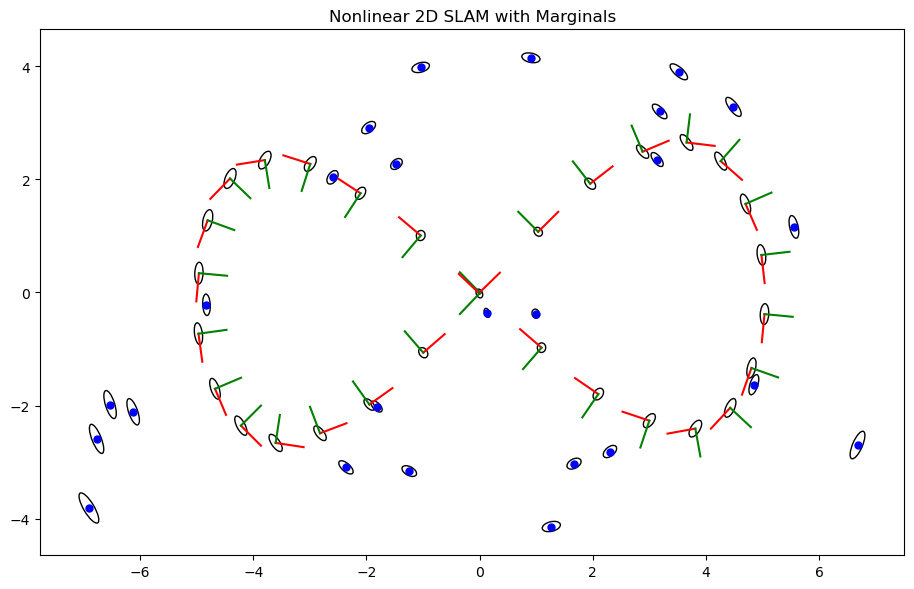

In [ ]:
from nonlinear.factor_graph_slam import SLAMConfig, FactorGraphSLAM, SLAMVisualizer

# Setup
config = SLAMConfig(
    prior_noise_sigmas=fgParams.P_x0_vec,
    odometry_noise_sigmas=fgParams.Q_vec,
    measurement_noise_sigmas=fgParams.R_vec,
    motion_sigma_x=fgParams.sigma_x,
    motion_sigma_y=fgParams.sigma_y,
    motion_sigma_theta=fgParams.sigma_theta,
    sensor_sigma_range=fgParams.sigma_range,
    sensor_sigma_bearing=fgParams.sigma_bearing
)

prior_pose = sim_data['measurements']['prior']
slam = FactorGraphSLAM(config, prior_pose)

# Main loop
for k in range(len(pose_vars)):
    # Get odometry (None for first step)
    if k == 0:
        odometry = None
    else:
        odometry, _, _ = sim_data['measurements']['odometry'][k - 1]
    
    # Get landmark measurements
    measurements = sim_data['measurements']['landmarks'][k]
    associations = sim_data['associations'][k]
    
    # Process step
    slam.process_step(odometry, measurements, associations)

# Visualize
marginals = slam.get_marginals()
SLAMVisualizer.plot_final_result(slam, marginals)
plt.show()

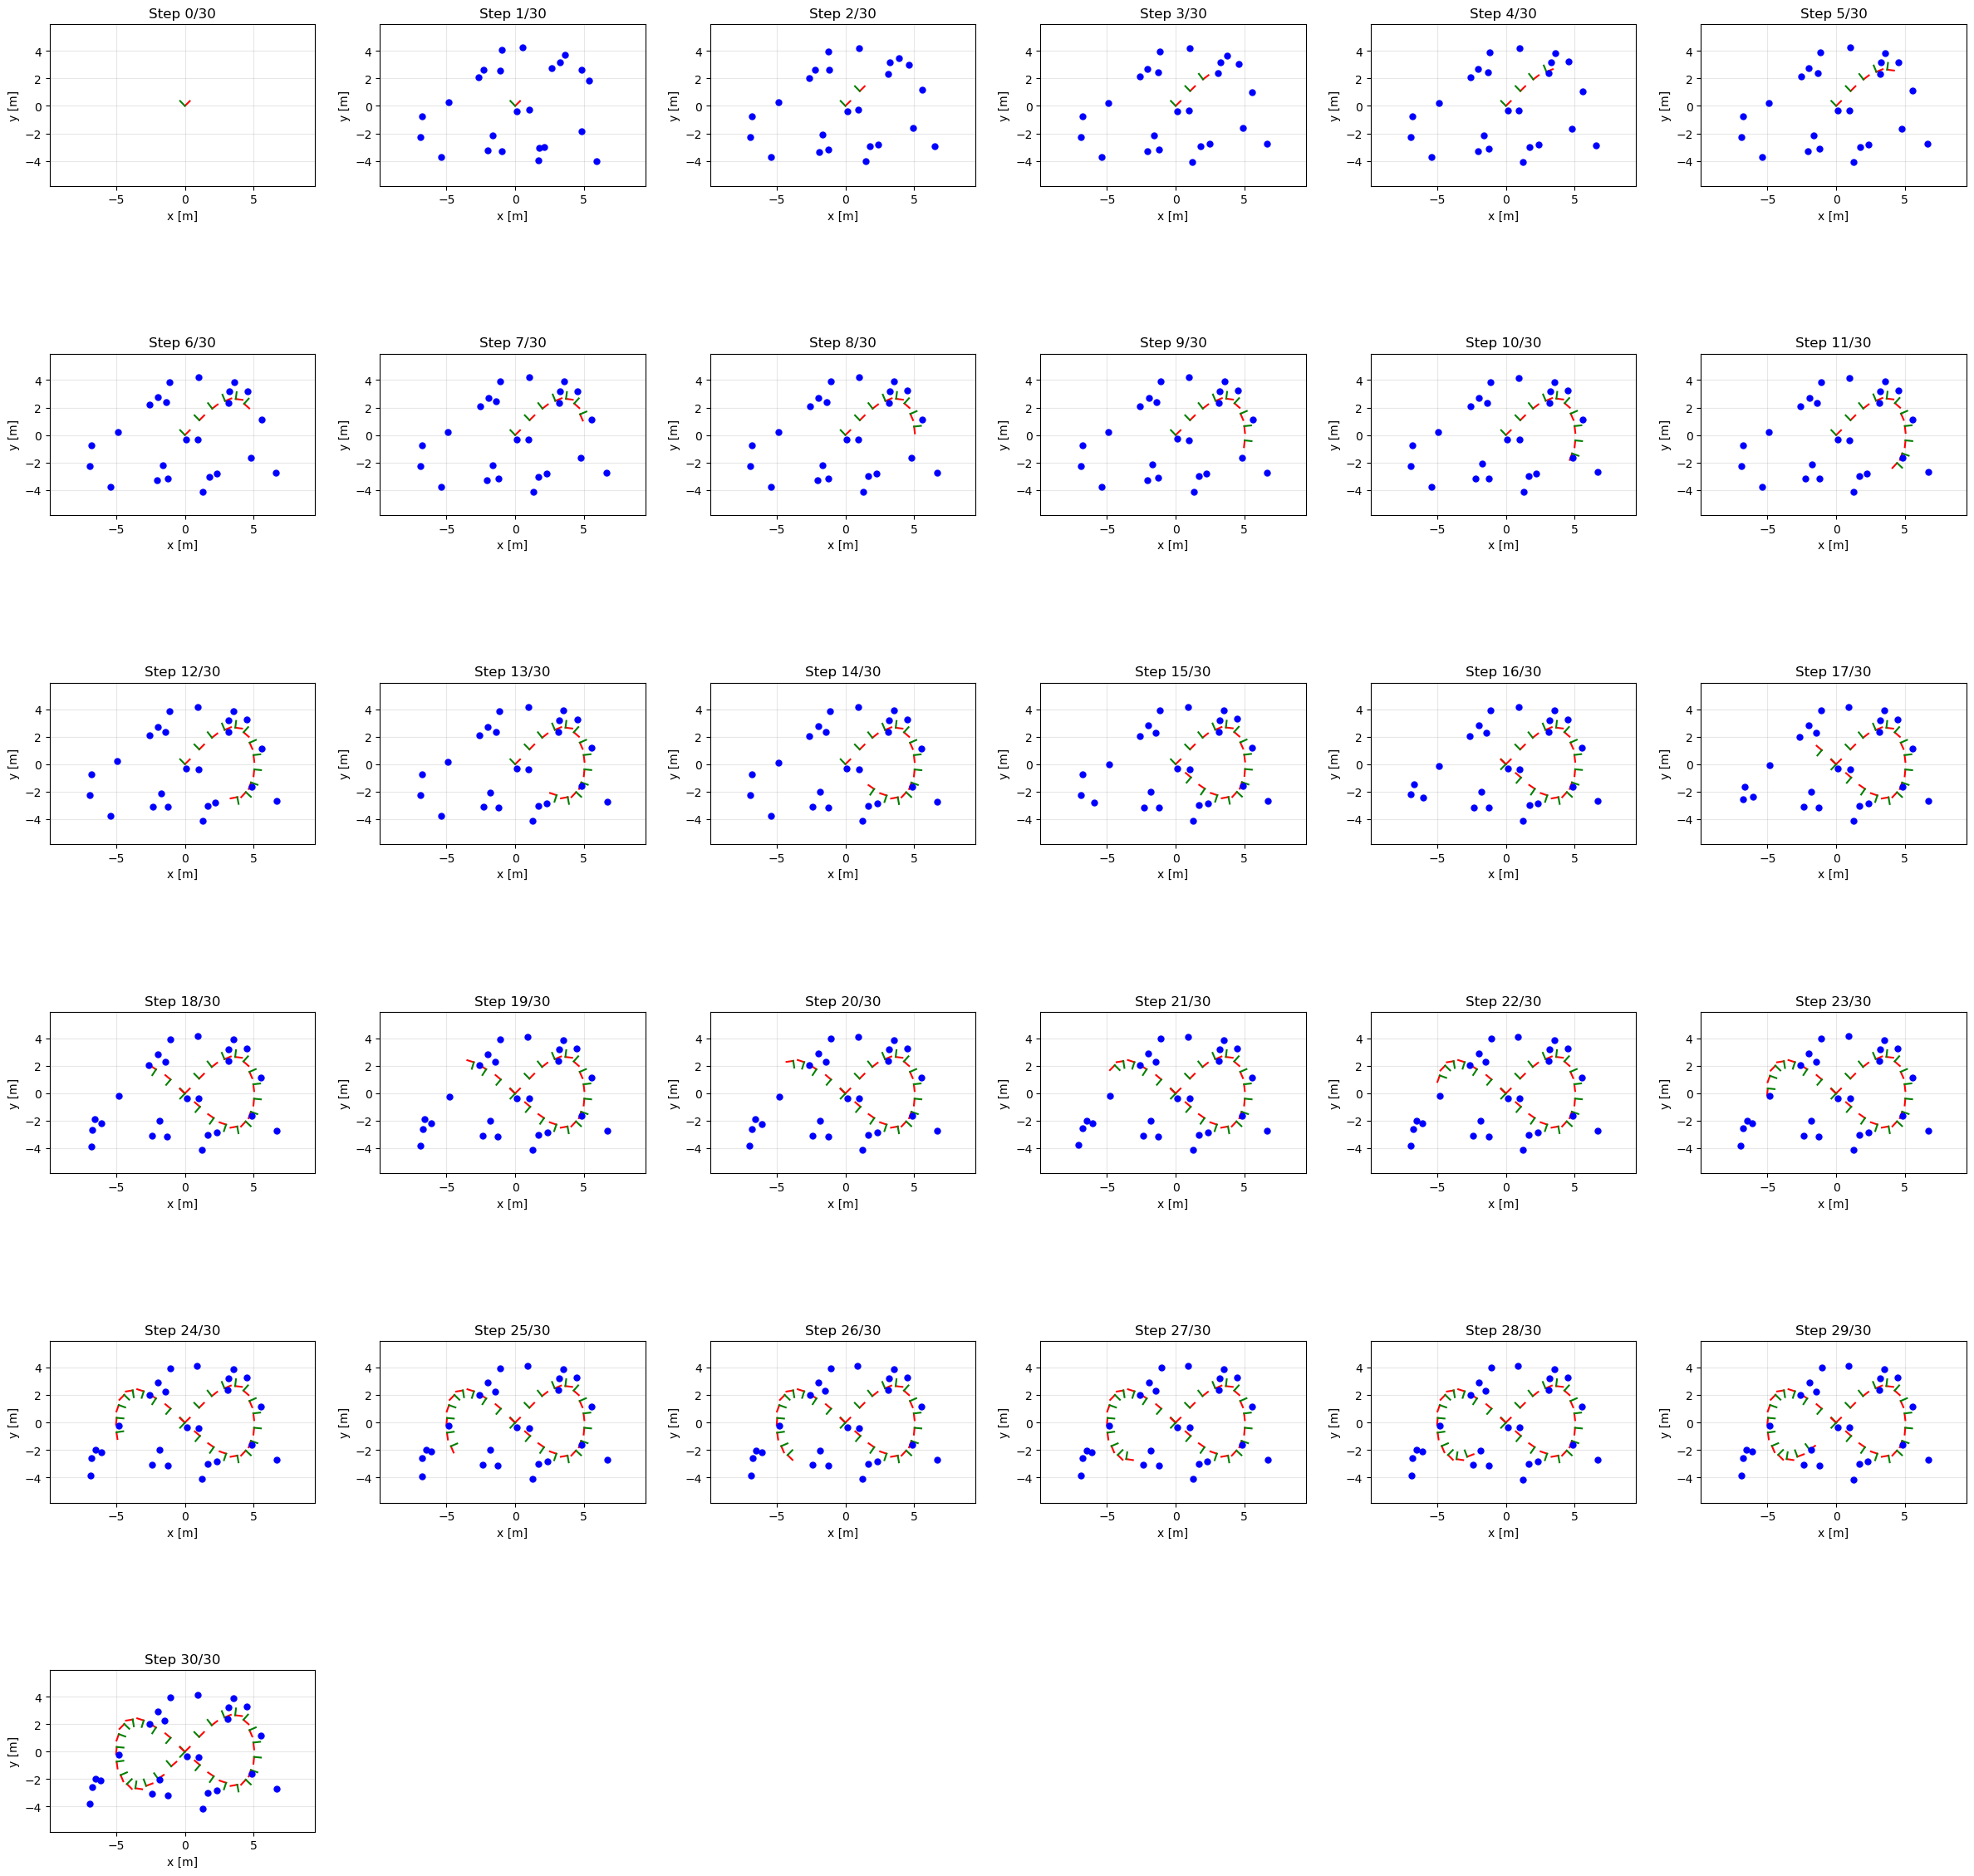

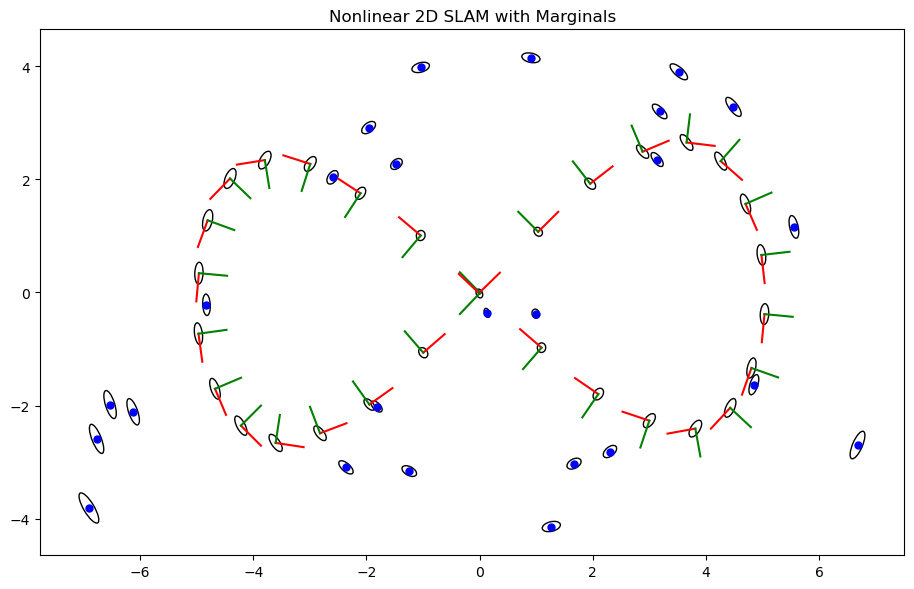

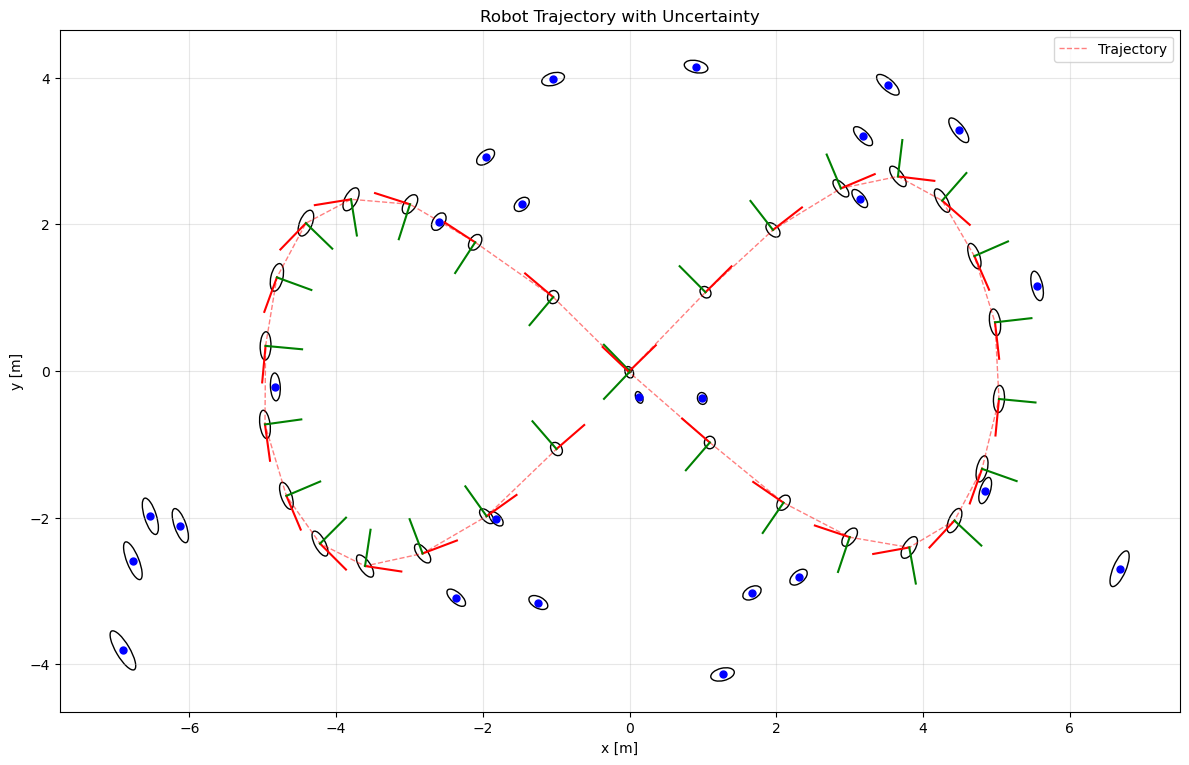

In [11]:
# After running SLAM...

# 1. Plot step-by-step evolution
fig, axes = SLAMVisualizer.plot_step_by_step(slam, subplot_size=4.0)
plt.show()

# 2. Plot final result with marginals
marginals = slam.get_marginals()
fig, ax = SLAMVisualizer.plot_final_result(slam, marginals)
plt.show()

# 3. Plot trajectory with uncertainty
fig, ax = SLAMVisualizer.plot_trajectory_with_uncertainty(slam)
plt.show()

### Raw loop

In [2]:
"""Rotation used for coordinate transformations of covariance between local and world frame"""
def E(theta):
    M = np.eye(3)
    M[:2,:2] = rotmat2(theta)
    return M

In [3]:
import gtsam
import numpy as np
import matplotlib.pyplot as plt
from gtsam.utils import plot as gtsam_plot
import copy

# --- Setup ---
K = len(pose_vars)

prior_noise_model = gtsam.noiseModel.Diagonal.Sigmas(fgParams.P_x0_vec)
odometry_noise_model = gtsam.noiseModel.Diagonal.Sigmas(fgParams.Q_vec)
measurement_noise_model = gtsam.noiseModel.Diagonal.Sigmas(fgParams.R_vec)
params = gtsam.LevenbergMarquardtParams()

graph = gtsam.NonlinearFactorGraph()
estimate = gtsam.Values()

motion_model = OdometrySE2(sigma_x=fgParams.sigma_x,
                           sigma_y=fgParams.sigma_y,
                           sigma_theta=fgParams.sigma_theta)
sens_model = RangeBearing(sigma_range=fgParams.sigma_range,
                          sigma_bearing=fgParams.sigma_bearing)

# --- Add prior factor ---
prior_mean = sim_data['measurements']['prior']
graph.add(gtsam.PriorFactorPose2(X(0), prior_mean, prior_noise_model))
estimate.insert(X(0), prior_mean)

# --- Initial optimization ---
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, estimate, params)
result = optimizer.optimize()

# --- Store all estimates for later visualization ---
estimates_over_time = [copy.deepcopy(result)]
added_landmarks_keys = []

# --- Main loop ---
for k in range(K):
    # Add odometry factors
    if k > 0:
        u_k, from_idx, to_idx = sim_data['measurements']['odometry'][k - 1]

        marginals = gtsam.Marginals(graph, estimate)

        graph.add(gtsam.BetweenFactorPose2(X(from_idx), X(to_idx), u_k, odometry_noise_model))
        
        x_prev = estimate.atPose2(X(from_idx))        

        gated_landmarks_keys = added_landmarks_keys
        state_keys = [X(k-1)] + gated_landmarks_keys


        P_prev = marginals.jointMarginalCovariance([X(k-1)] + gated_landmarks_keys).fullMatrix()
        P_prev = reorder_covariance_auto(P_prev, source_keys=sorted(state_keys), target_keys=state_keys, values=estimate)
        
        # Rotate covariance from local to global
        num_gated_landmarks = len(gated_landmarks_keys)
        E_prev = np.eye(3 + 2*num_gated_landmarks)
        E_prev[:3,:3] = E(x_prev.theta())
        g_P_prev = E_prev @ P_prev @ E_prev.T

        x_pred, g_Px_pred = motion_model.predict_pose(pose2_to_array(x_prev), g_P_prev[:3,:3], pose2_to_array(u_k))
        g_P_pred = g_P_prev
        g_P_pred[:3,:3] = g_Px_pred

        # Get specifed pose and landmarks and put into state vector
        m_pred = np.zeros(2 * num_gated_landmarks)
        for i, key in enumerate(gated_landmarks_keys):
            m_pred[2*i:2*(i+1)] = result.atPoint2(key)
        eta_pred = np.hstack((x_pred, m_pred))

        z_pred, S = sens_model.predict_measurements(eta_pred, g_P_pred)

        x_pred = x_prev.compose(u_k) # Predict next pose
        estimate.insert(X(to_idx), x_pred)

    # Add landmark measurement factors
    zs_k = sim_data['measurements']['landmarks'][k]
    #associations, new_landmarks = jcbb(zs_k, z_pred, S)
    ids = sim_data['associations'][k]  # Ground-truth associations from simulator

    for j, (z_range, z_bearing) in zip(ids, zs_k):
        graph.add(gtsam.BearingRangeFactor2D(X(k), L(j), z_bearing, z_range, measurement_noise_model))

        # Initialize landmark if first observed
        if not estimate.exists(L(j)):
            delta_x = z_range * np.cos(z_bearing.theta())
            delta_y = z_range * np.sin(z_bearing.theta())
            predicted_pose = estimate.atPose2(X(k))
            landmark_initial = predicted_pose.transformFrom(gtsam.Point2(delta_x, delta_y))
            estimate.insert(L(j), landmark_initial)
            added_landmarks_keys.append(L(j))

    # Optimize after each step
    optimizer = gtsam.LevenbergMarquardtOptimizer(graph, estimate, params)
    result = optimizer.optimize()

    # Store result for visualization
    estimates_over_time.append(copy.deepcopy(result))

    # Update estimate for next iteration
    estimate = result

# --- Compute marginals for final result ---
marginals = gtsam.Marginals(graph, result)

# --- Plot final result ---
fig, axs = plt.subplots(1, 1, figsize=(22, 6))
axs.set_aspect('equal')
axs.set_title("Nonlinear 2D SLAM with Marginals")

for var in all_vars:
    cov = marginals.marginalCovariance(var)
    if kstr(var)[0] == 'X':
        mean = result.atPose2(var)
        gtsam_plot.plot_pose2_on_axes(axs, pose=mean, axis_length=0.5, covariance=cov)
    elif kstr(var)[0] == 'L':
        mean = result.atPoint2(var)
        gtsam_plot.plot_point2_on_axes(axs, point=mean, linespec='b', P=cov)

plt.tight_layout()
plt.show()


NameError: name 'pose_vars' is not defined

In [4]:
from IPython.display import display

plt.ioff()  # Turn interactive mode off for static multi-plot display

# Create K subplots (arranged in a square-ish grid)
K = len(estimates_over_time)
cols = int(np.ceil(np.sqrt(K)))
rows = int(np.ceil(K / cols))

# Compute global axis limits across all saved estimates (poses + landmarks)
xs = []
ys = []
for est in estimates_over_time:
    for var in all_vars:
        if est.exists(var):
            if kstr(var)[0] == 'X':
                p = est.atPose2(var)
                xs.append(p.x())
                ys.append(p.y())
            elif kstr(var)[0] == 'L':
                l = est.atPoint2(var)
                xs.append(l[0])
                ys.append(l[1])

# Fallback if nothing collected
if len(xs) == 0:
    xs = [0]
    ys = [0]

xmin, xmax = min(xs), max(xs)
ymin, ymax = min(ys), max(ys)
# Add margin (20% of the max span, but at least 0.5 m)
xspan = max(1e-3, xmax - xmin)
yspan = max(1e-3, ymax - ymin)
margin_frac = 0.2
x_margin = max(0.5, margin_frac * xspan)
y_margin = max(0.5, margin_frac * yspan)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
# Flatten axes for easy indexing
if isinstance(axes, np.ndarray):
    axes_flat = axes.flatten()
else:
    axes_flat = [axes]

for idx, est in enumerate(estimates_over_time):
    ax = axes_flat[idx]
    ax.set_aspect('equal')
    ax.set_title(f"Iteration {idx+1}/{K}")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")

    # Plot current poses and landmarks
    for var in all_vars:
        label = kstr(var)[0]
        if label == 'X' and est.exists(var):
            gtsam_plot.plot_pose2_on_axes(ax, est.atPose2(var), axis_length=0.5)
        elif label == 'L' and est.exists(var):
            gtsam_plot.plot_point2_on_axes(ax, est.atPoint2(var), linespec='b')

    # Apply the SAME global limits to each axis
    ax.set_xlim(xmin - x_margin, xmax + x_margin)
    ax.set_ylim(ymin - y_margin, ymax + y_margin)

# Hide any unused axes
for i in range(K, len(axes_flat)):
    fig.delaxes(axes_flat[i])

plt.tight_layout()
plt.show()

NameError: name 'estimates_over_time' is not defined